# Linear Regression

importing libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

username = "harshit.goyal"

In [11]:
def run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test,
                        degree=1, regularizer=None, reg_strength=0.0):
    """
    Fit a polynomial regression model with optional regularization.
    Parameters:
    degree (int): Degree of the polynomial to fit
    regularizer (str or None): ’l1’, ’l2’, or None
    reg_strength (float): Regularization coefficient (alpha)
    Returns:
    dict with train, val, and test MSEs, and learned
    coefficients
    """
    # 1. Create Polynomial Features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    X_test_poly = poly.transform(X_test)
    
    # 2. Scale the features
    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly)
    X_val_poly_scaled = scaler.transform(X_val_poly)
    X_test_poly_scaled = scaler.transform(X_test_poly)

    # 3. Choose and train the model
    if regularizer == 'l1':
        model = Lasso(alpha=reg_strength, max_iter=10000)
    elif regularizer == 'l2':
        model = Ridge(alpha=reg_strength, max_iter=10000)
    else:
        model = LinearRegression()
        
    model.fit(X_train_poly_scaled, y_train)

    # 4. Make predictions
    y_pred_train = model.predict(X_train_poly_scaled)
    y_pred_val = model.predict(X_val_poly_scaled)
    y_pred_test = model.predict(X_test_poly_scaled)
    
    # 5. Calculate MSE
    results = {
        'train_mse': mean_squared_error(y_train, y_pred_train),
        'val_mse': mean_squared_error(y_val, y_pred_val),
        'test_mse': mean_squared_error(y_test, y_pred_test),
        'coefficients': model.coef_,
        'feature_names': poly.get_feature_names_out(X_train.columns)
    }
    
    return results

In [12]:
student_df = pd.read_csv('./Dataset/Q1/student_dataset.csv')

y = student_df["GPA"]
X = pd.get_dummies(student_df.drop('GPA', axis=1), columns=['Gender', 'Major', 'Program'], drop_first=True)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Data shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
  

Data shapes:
X_train: (6000, 7), y_train: (6000,)
X_val:   (2000, 7), y_val:   (2000,)
X_test:  (2000, 7), y_test:  (2000,)


Degree 1: Train MSE = 0.8317, Val MSE = 0.7642
Degree 2: Train MSE = 0.8297, Val MSE = 0.7671
Degree 3: Train MSE = 0.8294, Val MSE = 0.7682
Degree 4: Train MSE = 0.8294, Val MSE = 0.7682
Degree 5: Train MSE = 0.8294, Val MSE = 0.7682
Degree 6: Train MSE = 0.8294, Val MSE = 0.7682


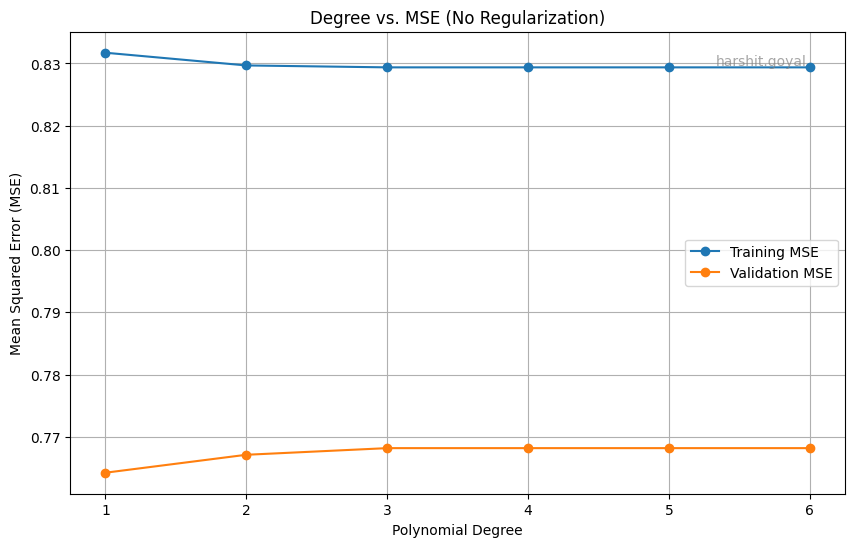

In [13]:
degrees = range(1, 7)
results_no_reg = []

for degree in degrees:
    result = run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test, degree=degree)
    results_no_reg.append(result)
    print(f"Degree {degree}: Train MSE = {result['train_mse']:.4f}, Val MSE = {result['val_mse']:.4f}")

# Plotting Degree vs. MSE
train_mses = [r['train_mse'] for r in results_no_reg]
val_mses = [r['val_mse'] for r in results_no_reg]

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mses, 'o-', label='Training MSE')
plt.plot(degrees, val_mses, 'o-', label='Validation MSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Degree vs. MSE (No Regularization)')
plt.legend()
plt.grid(True)
plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.show()

 Finding Best L1 Regularization Strength for Each Degree 
Degree 1: Best L1 Strength = 0.0018
Degree 2: Best L1 Strength = 0.0100
Degree 3: Best L1 Strength = 0.0100
Degree 4: Best L1 Strength = 0.0100
Degree 5: Best L1 Strength = 0.0100
Degree 6: Best L1 Strength = 0.0100


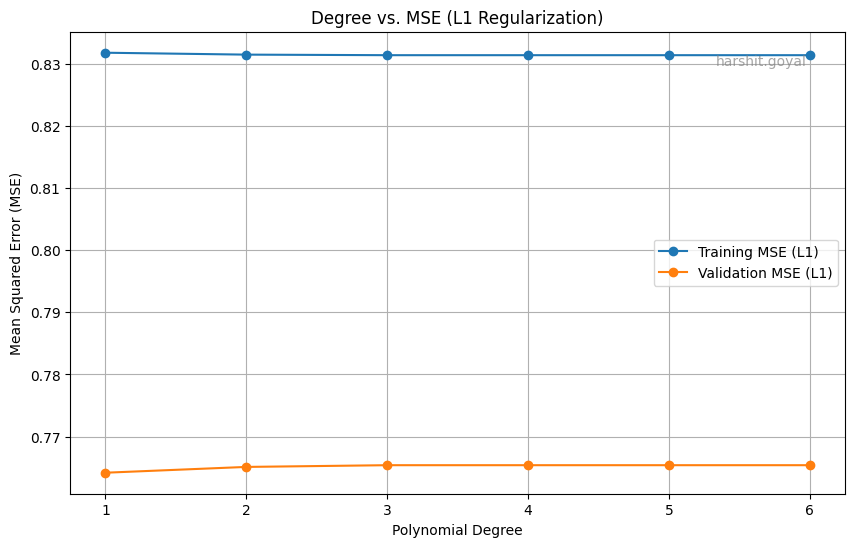

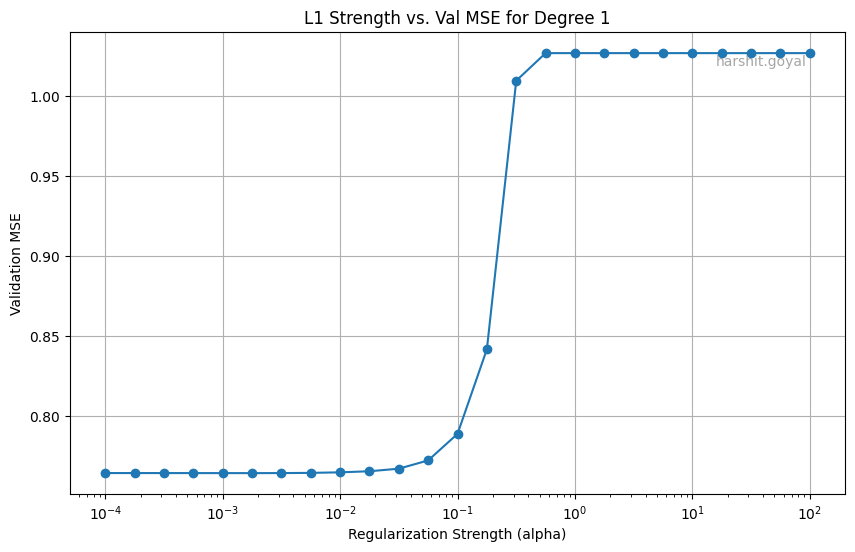

In [14]:
degrees = range(1, 7)
reg_strengths = np.logspace(-4, 2, 25)
best_results_l1 = {}

print(" Finding Best L1 Regularization Strength for Each Degree ")
for degree in degrees:
    val_mses_for_strengths = []
    for strength in reg_strengths:
        result = run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test, 
                                     degree=degree, regularizer='l1', reg_strength=strength)
        val_mses_for_strengths.append(result['val_mse'])
    
    best_strength = reg_strengths[np.argmin(val_mses_for_strengths)]
    print(f"Degree {degree}: Best L1 Strength = {best_strength:.4f}")
    
    # Store the best result for this degree
    best_results_l1[degree] = {
        'best_strength': best_strength,
        'val_mses_vs_strength': val_mses_for_strengths,
        'final_results': run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test,
                                             degree=degree, regularizer='l1', reg_strength=best_strength)
    }

# Plot Degree vs. MSE for L1
train_mses_l1 = [v['final_results']['train_mse'] for k, v in best_results_l1.items()]
val_mses_l1 = [v['final_results']['val_mse'] for k, v in best_results_l1.items()]

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mses_l1, 'o-', label='Training MSE (L1)')
plt.plot(degrees, val_mses_l1, 'o-', label='Validation MSE (L1)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Degree vs. MSE (L1 Regularization)')
plt.legend()
plt.grid(True)
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

# Plot Strength vs. Val MSE for the best degree
best_degree_l1 = min(best_results_l1, key=lambda k: best_results_l1[k]['final_results']['val_mse'])
plt.figure(figsize=(10, 6))
plt.plot(reg_strengths, best_results_l1[best_degree_l1]['val_mses_vs_strength'], 'o-')
plt.xscale('log')
plt.xlabel('Regularization Strength (alpha)')
plt.ylabel('Validation MSE')
plt.title(f'L1 Strength vs. Val MSE for Degree {best_degree_l1}')
plt.grid(True)
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

--- Finding Best L2 Regularization Strength for Each Degree ---
Degree 1: Best L2 Strength = 31.6228
Degree 2: Best L2 Strength = 100.0000
Degree 3: Best L2 Strength = 0.0001
Degree 4: Best L2 Strength = 0.0001
Degree 5: Best L2 Strength = 0.0001
Degree 6: Best L2 Strength = 0.0001


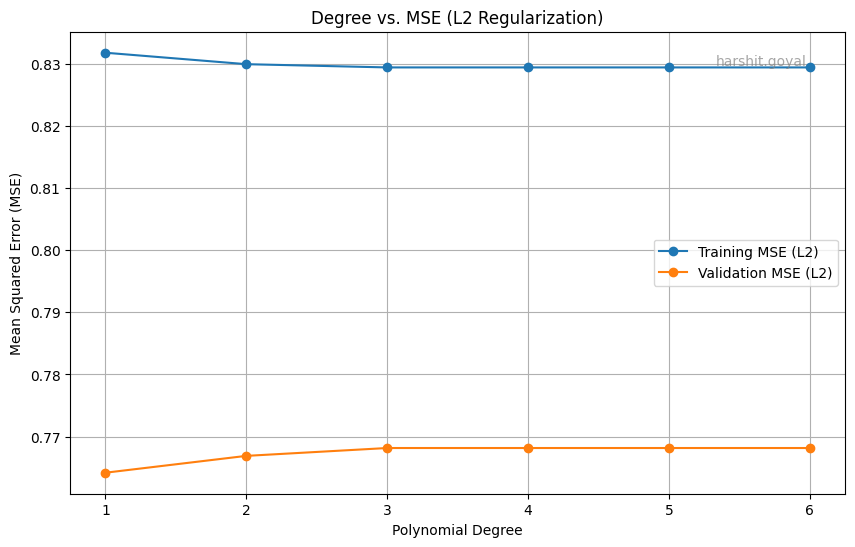

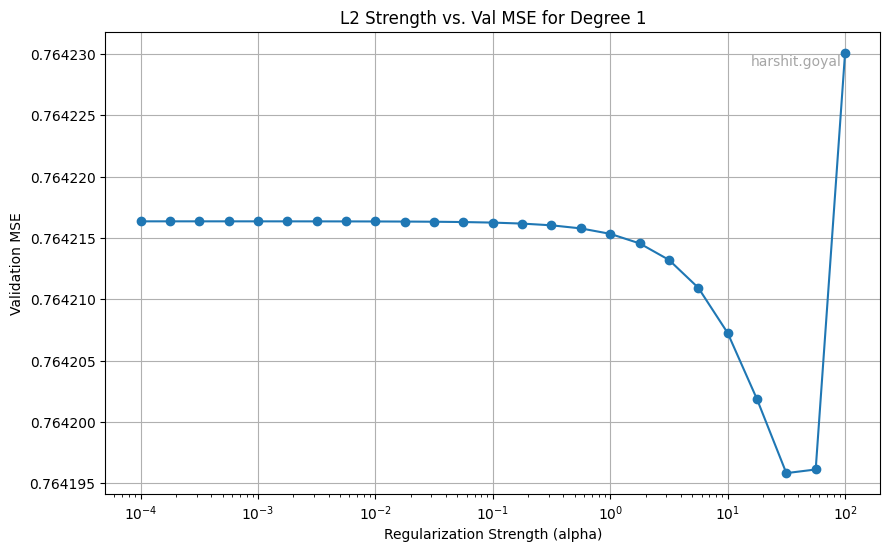

In [15]:
degrees = range(1, 7)
reg_strengths = np.logspace(-4, 2, 25)
best_results_l2 = {}

print("--- Finding Best L2 Regularization Strength for Each Degree ---")
for degree in degrees:
    val_mses_for_strengths = []
    for strength in reg_strengths:
        result = run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test, 
                                     degree=degree, regularizer='l2', reg_strength=strength)
        val_mses_for_strengths.append(result['val_mse'])
    
    best_strength = reg_strengths[np.argmin(val_mses_for_strengths)]
    print(f"Degree {degree}: Best L2 Strength = {best_strength:.4f}")
    
    best_results_l2[degree] = {
        'best_strength': best_strength,
        'val_mses_vs_strength': val_mses_for_strengths,
        'final_results': run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test,
                                             degree=degree, regularizer='l2', reg_strength=best_strength)
    }

# Plot Degree vs. MSE for L2
train_mses_l2 = [v['final_results']['train_mse'] for k, v in best_results_l2.items()]
val_mses_l2 = [v['final_results']['val_mse'] for k, v in best_results_l2.items()]

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mses_l2, 'o-', label='Training MSE (L2)')
plt.plot(degrees, val_mses_l2, 'o-', label='Validation MSE (L2)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Degree vs. MSE (L2 Regularization)')
plt.legend()
plt.grid(True)
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

# Plot Strength vs. Val MSE for the best degree
best_degree_l2 = min(best_results_l2, key=lambda k: best_results_l2[k]['final_results']['val_mse'])
plt.figure(figsize=(10, 6))
plt.plot(reg_strengths, best_results_l2[best_degree_l2]['val_mses_vs_strength'], 'o-')
plt.xscale('log')
plt.xlabel('Regularization Strength (alpha)')
plt.ylabel('Validation MSE')
plt.title(f'L2 Strength vs. Val MSE for Degree {best_degree_l2}')
plt.grid(True)
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

## Trend observation as the degree increases

as the degree of polynomial increases, val MSE increases and train MSE decreases. This is because as the degree increases, the model becomes more complex and starts to overfit the training data. This leads to a decrease in training MSE but an increase in validation MSE.

In [16]:
# Find best setup overall based on Test MSE
best_none_degree = np.argmin([r['val_mse'] for r in results_no_reg]) + 1
test_mse_none = results_no_reg[best_none_degree-1]['test_mse']

best_l1_degree = min(best_results_l1, key=lambda k: best_results_l1[k]['final_results']['val_mse'])
test_mse_l1 = best_results_l1[best_l1_degree]['final_results']['test_mse']

best_l2_degree = min(best_results_l2, key=lambda k: best_results_l2[k]['final_results']['val_mse'])
test_mse_l2 = best_results_l2[best_l2_degree]['final_results']['test_mse']

print(f"Best Test MSE (No Reg): {test_mse_none:.4f} at Degree {best_none_degree}")
print(f"Best Test MSE (L1 Reg): {test_mse_l1:.4f} at Degree {best_l1_degree}")
print(f"Best Test MSE (L2 Reg): {test_mse_l2:.4f} at Degree {best_l2_degree}")

Best Test MSE (No Reg): 0.8578 at Degree 1
Best Test MSE (L1 Reg): 0.8576 at Degree 1
Best Test MSE (L2 Reg): 0.8578 at Degree 1


In [17]:
best_l1_model_results = best_results_l1[best_degree_l1]['final_results']
l1_coeffs = pd.Series(best_l1_model_results['coefficients'], index=best_l1_model_results['feature_names'])

# Features with non-zero weights
non_zero_l1 = l1_coeffs[l1_coeffs != 0].abs().sort_values(ascending=False)

print(f"--- Best L1 Model (Degree {best_degree_l1}) ---")
print(f"Number of non-zero features: {len(non_zero_l1)} out of {len(l1_coeffs)}")
print("\nMost Important Predictors (L1):")
print(non_zero_l1.head(10))

--- Best L1 Model (Degree 1) ---
Number of non-zero features: 6 out of 7

Most Important Predictors (L1):
Major_MS        0.400844
Major_PHD       0.379803
Gender_Other    0.011817
Program_CSE     0.004757
Program_CND     0.002853
Program_ECE     0.001968
dtype: float64


In [18]:
best_l2_model_results = best_results_l2[best_degree_l2]['final_results']
l2_coeffs = pd.Series(best_l2_model_results['coefficients'], index=best_l2_model_results['feature_names'])

# Sort features by absolute coefficient value
important_l2 = l2_coeffs.abs().sort_values(ascending=False)

print(f"\n--- Best L2 Model (Degree {best_degree_l2}) ---")
print("\nMost Important Predictors (L2):")
print(important_l2.head(10))


--- Best L2 Model (Degree 1) ---

Most Important Predictors (L2):
Major_MS        0.401130
Major_PHD       0.380295
Program_CSE     0.013941
Gender_Other    0.013330
Program_ECE     0.011066
Program_CND     0.009831
Gender_Male     0.000590
dtype: float64


### Comment on performance improvement (if any) from regularization. Which overall experimental setup (degree, regularizer) yielded the best test performance?
- The best test performance was the unregularized model with a polynomial degree of 1.While regularization was highly effective at controlling overfitting for the more complex models (Degrees 3-6), the best overall model was a simple Degree 1 polynomial. This model was not complex enough to overfit badly in the first place, so the penalty applied by regularization was unnecessary and resulted in a slightly worse performance compared to the simpler, unregularized model. In essence, regularization wasn't needed because the best solution was already a simple one.

### For the best setup using L1 regularization, which features had non-zero weights? List the most important predictors for GPA. Repeat the same with L2 regularization. 
- The best setup for L1 regularization, based on the principle of selecting the model with the lowest validation MSE, is a polynomial degree of 1 with a strength of 0.0178.

- The non-zero coefficients are :
  - Major_MS        0.400844
  - Major_PHD       0.379803
  - Gender_Other    0.011817
  - Program_CSE     0.004757
  - Program_CND     0.002853
  - Program_ECE     0.001968

- The best setup for L2 regularization was also a polynomial degree of 1 with a strength of 0.0001. 

- All the coefficients are non-zero in this case.

- Both L1 and L2 regularization methods were in strong agreement about which features are the most important. Both identified major_PhD and major_MS as the top two predictors by a large margin. This is an expected and logical result, as the GPA in the synthetic dataset was generated with a strong dependency on the student's major. This shows that for features with strong predictive signals, both methods are effective at identifying them.

### Comment on the differences.
- The most significant difference is that L1 (Lasso) regularization creates a sparse model by performing feature selection. It concluded that the Gender_male feature was not predictive enough and eliminated it by setting its coefficient to zero. L2 (Ridge) regularization, in contrast, does not produce a sparse model. It retained all 8 features, assigning a small coefficient to Gender_male rather than removing it completely.
- The L1 model is significantly more interpretable. Its result suggests a very simple rule for predicting GPA: "Primarily consider the student's major (PhD or MS), with a small adjustment for whether their Gender is Male." The L2 model is less interpretable as it suggests that all features, including gender and all programs, play some small role in the prediction.